Part A — backpropagation and the update rule

TASK 01

A backward pass by hand

Trace derivatives backward through a tiny network — the core of how models learn.

In [11]:
import numpy as np

x = 3
w = 1.0
target = 12.0

# Forward Pass
a = w * x
loss = (a - target) ** 2

print("----- Forward Pass -----")
print("a =", a)
print("loss =", loss)

# Backward pass
dloss_da = 2 * (a - target)
da_dw = x
dloss_dw = dloss_da * da_dw

print("\n----- Backward Pass -----")
print("d(loss)/d(a) =", dloss_da)
print("d(a)/d(w) =", da_dw)
print("d(loss)/d(w) =", dloss_dw)

# Numerical Gradient
eps = 1e-5

# Loss when w is slightly increased
w_plus = w + eps
a_plus = w_plus * x
loss_plus = (a_plus - target) ** 2

# Loss when w is slightly decreased
w_minus = w - eps
a_minus = w_minus * x
loss_minus = (a_minus - target) ** 2

# Numerical derivative
numerical_grad = (loss_plus - loss_minus) / (2 * eps)

print("\n----- Numerical Verification -----")
print("Loss at w + eps =", loss_plus)
print("Loss at w - eps =", loss_minus)
print("Numerical Gradient =", numerical_grad)
print("Analytical Gradient =", dloss_dw)
print("Gradient Match :", np.isclose(numerical_grad, dloss_dw))

# Read Gradient Sign
print("\n----- Gradient Sign -----")

if dloss_dw > 0:
    print("Gradient is positive -> w should decrease.")

elif dloss_dw < 0:
    print("Gradient is negative -> w should increase.")

else :
    print("Gradient is zero -> w is already at a minimum.")

# One Gradient Descent Update
lr = 0.05

w_new = w - lr * dloss_dw

print("\n----- Weight Update -----")
print("Old w =", w)
print("Learning Rate =", lr)
print("Gradient =", dloss_dw)
print("New w =", w_new)

# Forward Pass After Update
a_new = w_new * x
new_loss = (a_new - target)**2

print("\n----- After Update -----")
print("New a =", a_new)
print("New loss =", new_loss)

# Confirms Loss Drops 
print("\n----- Final Check -----")
print("Old Loss =", loss)
print("New Loss =", new_loss)
print("Did loss increase? =", new_loss < loss)

----- Forward Pass -----
a = 3.0
loss = 81.0

----- Backward Pass -----
d(loss)/d(a) = -18.0
d(a)/d(w) = 3
d(loss)/d(w) = -54.0

----- Numerical Verification -----
Loss at w + eps = 80.99946000089999
Loss at w - eps = 81.00054000089997
Numerical Gradient = -53.99999999937676
Analytical Gradient = -54.0
Gradient Match : True

----- Gradient Sign -----
Gradient is negative -> w should increase.

----- Weight Update -----
Old w = 1.0
Learning Rate = 0.05
Gradient = -54.0
New w = 3.7

----- After Update -----
New a = 11.100000000000001
New loss = 0.8099999999999974

----- Final Check -----
Old Loss = 81.0
New Loss = 0.8099999999999974
Did loss increase? = True


TASK 02

Gradient descent from scratch

The curriculum's core deliverable. Build the optimiser once, reuse it everywhere.

First six positions :
[0, 1.0, 1.8, 2.4400000000000004, 2.9520000000000004, 3.3616]

Final Position :
4.942353924769658

Distance from minimum x=5 :
0.05764607523034204

Gradient descent has not exactly reached x = 5 yet.

Second Function :
g(x) = (x + 3)^2 + 2
Starting Position : 5
Final Position : -2.9900964796857172
Known minimum: x = -3
Gradient descent is approaching the minimum.


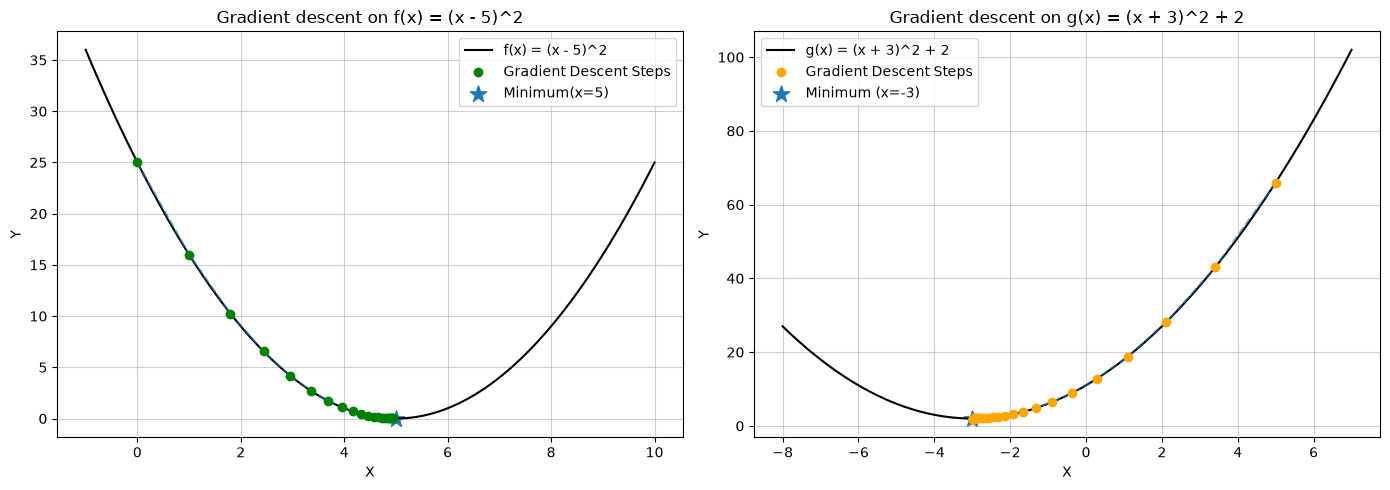

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Gradient Descent Function
def gradient_descent(grad_fn, start, lr, steps) :
    x = start
    history = [x]

    for _ in range(steps):
        x = x - lr * grad_fn(x)
        history.append(x)

    return history

# Function 1: f(x) = (x-5)²
# Gradient: f'(x) = 2(x - 5)
def f(x):
    return (x - 5) ** 2

def grad_f(x):
    return 2 * (x - 5)

# Gradient Descent
history = gradient_descent(grad_fn=grad_f, start=0, lr=0.1, steps=20)

print("First six positions :")
print(history[:6])
print("\nFinal Position :")
print(history[-1])
print("\nDistance from minimum x=5 :")
print(abs(history[-1] - 5))

# Confirm it reaches x=5
if np.isclose(history[-1], 5):
    print("\nGradient descent reached the minimum x = 5.")
else :
    print("\nGradient descent has not exactly reached x = 5 yet.")


# Function 2: g(x) = (x + 3)^2 + 2
# Known minimum: x = -3
def g(x):
    return (x + 3)**2 + 2

def grad_g(x):
    return 2 * (x + 3)

history2 = gradient_descent(grad_fn=grad_g, start=5, lr=0.1, steps=30)

print("\nSecond Function :")
print("g(x) = (x + 3)^2 + 2")

print("Starting Position :", history2[0])
print("Final Position :", history2[-1])
print("Known minimum: x = -3")

if np.isclose(history[-1], -3):
    print("Gradient descent found the known minimum.")
else:
    print("Gradient descent is approaching the minimum.")



# Plot function and gradient descent steps
fig, ax = plt.subplots(1, 2, figsize=(14, 5))


x_values = np.linspace(-1, 10, 500)
y_values = f(x_values)

ax[0].plot(x_values, y_values, color="black", label="f(x) = (x - 5)^2")

history_y = [f(x) for x in history]

ax[0].scatter(history, history_y, color="green", label="Gradient Descent Steps", zorder=3)

ax[0].plot(history, history_y, linestyle="--", alpha=0.6)

ax[0].scatter(5, 0, marker="*", s=150, label="Minimum(x=5)")

ax[0].set_xlabel("X")
ax[0].set_ylabel("Y")
ax[0].set_title("Gradient descent on f(x) = (x - 5)^2")
ax[0].legend()
ax[0].grid(alpha=0.6)

# Plot second function
x_values2 = np.linspace(-8, 7, 500)
y_values2 = g(x_values2)

ax[1].plot(x_values2, y_values2, color="black", label="g(x) = (x + 3)^2 + 2")

history2_y = [g(x) for x in history2]

ax[1].scatter(history2, history2_y, color="orange", label="Gradient Descent Steps", zorder=3)

ax[1].plot(history2, history2_y, linestyle="--", alpha=0.6)

ax[1].scatter(-3, 2, marker="*", s=150, label="Minimum (x=-3)")

ax[1].set_xlabel("X")
ax[1].set_ylabel("Y")
ax[1].set_title("Gradient descent on g(x) = (x + 3)^2 + 2")
ax[1].legend()
ax[1].grid(alpha=0.6)


plt.tight_layout()
plt.show()

Part B — learning rates and the landscape

TASK 03

Sweep the learning rate until it breaks

The curriculum's learning-rate activity. Feel the three behaviours yourself.

Final position after 60 steps:
-------------------------------
0.001 -> 0.5659306472654195
0.01 -> 3.512234286539396
0.1 -> 4.999992337522295
0.5 -> 5.0
0.9 -> 4.999992337522295
1.0 -> 0.0
1.05 -> -1517.4081977070985


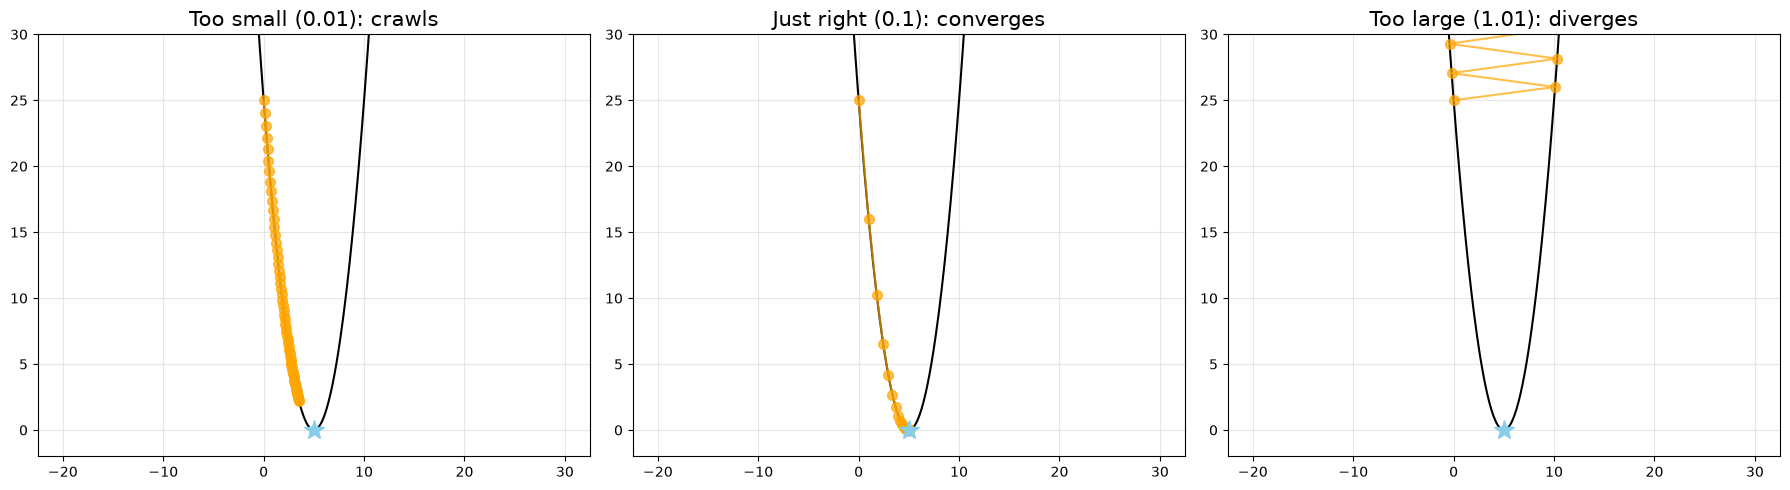


Checking learning rates around the threshold:
-----------------------------------------------
LR = 0.99 Final x = 1.6619601412245268
LR = 1.0 Final x = 0.0
LR = 1.01 Final x = -2.4297369798917767
LR = 1.05 Final x = -28.637499746628066
LR = 1.1 Final x = -186.68799962237426

Diverging run: LR = 1.05
-------------------------
Step 0 -> x = 0.0
Step 1 -> x = 10.5
Step 2 -> x = -1.0500000000000007
Step 3 -> x = 11.655000000000001
Step 4 -> x = -2.3205000000000027
Step 5 -> x = 13.052550000000004
Step 6 -> x = -3.857805000000006
Step 7 -> x = 14.743585500000009
Step 8 -> x = -5.7179440500000105
Step 9 -> x = 16.789738455000013
Step 10 -> x = -7.968712300500016


In [43]:
import numpy as np
import matplotlib.pyplot as plt

# Gradient descent function
def gradient_descent(grad_fn, start, lr, steps):
    x = start
    history = [x]

    for _ in range(steps):
        x = x - lr * grad_fn(x)
        history.append(x)

    return history

# Function: f(x) = (x - 5)^2
# Gradient: f'(x) = 2(x - 5)
def f(x):
    return (x - 5) ** 2

def grad(x):
    return 2 * (x - 5)

# Test different learning rates
learning_rates = [0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.05]

print("Final position after 60 steps:")
print("-------------------------------")

for lr in learning_rates:
    path = gradient_descent(grad, 0.0, lr, 60)
    print(lr, "->", path[-1])

# Plot three descent paths

# Too small path
path_small = gradient_descent(grad, 0.0, 0.01, 60)

# Just right
path_good = gradient_descent(grad, 0.0, 0.1, 60)

# Too large
path_large = gradient_descent(grad, 0.0, 1.01, 20)

# x values for plotting the function
x_values = np.linspace(-20, 30, 500)
y_values = f(x_values)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Graph 1 : Too small
for ax, path, lr, ttl, in [(ax[0], path_small, 0.01, "Too small (0.01): crawls"),
                     (ax[1], path_good, 0.1, "Just right (0.1): converges"),
                     (ax[2], path_large, 1.01, "Too large (1.01): diverges")]:

    ax.plot(x_values, y_values, color="black", lw=1.5)
    ax.plot(path, f(np.array(path)), "o-", color="orange", alpha=0.7, markersize=7)
    ax.plot(5, 0, "*", color="skyblue", markersize=15)
    ax.set_title(ttl, fontsize=15)
    ax.grid(alpha=0.3)
    ax.set_ylim(-2, 30)

plt.tight_layout()
plt.show()

# Find divergence threshold
print("\nChecking learning rates around the threshold:")
print("-----------------------------------------------")

for lr in [0.99, 1.0, 1.01, 1.05, 1.1]:
    path = gradient_descent(grad, 0.0, lr, 20)

    print("LR =", lr, "Final x =", path[-1])


# Watch a diverging run
print("\nDiverging run: LR = 1.05")
print("-------------------------")

path = gradient_descent(grad, 0.0, 1.05, 10)

for step, x in enumerate(path):
    print("Step", step, "-> x =", x)

A too-large learning rate makes each update overshoot the minimum and jump to the opposite side of x=5. Each subsequent step overshoots even farther, so the distance from the minimum grows instead of shrinking, causing the values to diverge.

TASK 04

Local minima and convexity

The curriculum's local-vs-global topic. See the starting point decide the outcome.

start -2.0 -> ends -1.439
start -0.5 -> ends -1.439
start 0.5 -> ends 1.389
start 2.2 -> ends 1.389


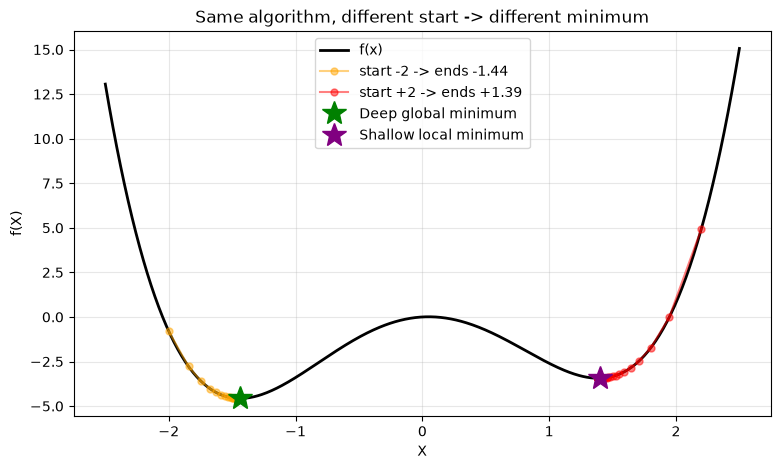

Global minimum (deepest) is on LEFT, near x = -1.44
Shallow local minimum is on RIGHT, near x = +1.40

Convex Function: g(x) = (x - 2)^2
start -5 -> ends 2.000
start -1 -> ends 2.000
start 0 -> ends 2.000
start 3 -> ends 2.000
start 8 -> ends 2.000


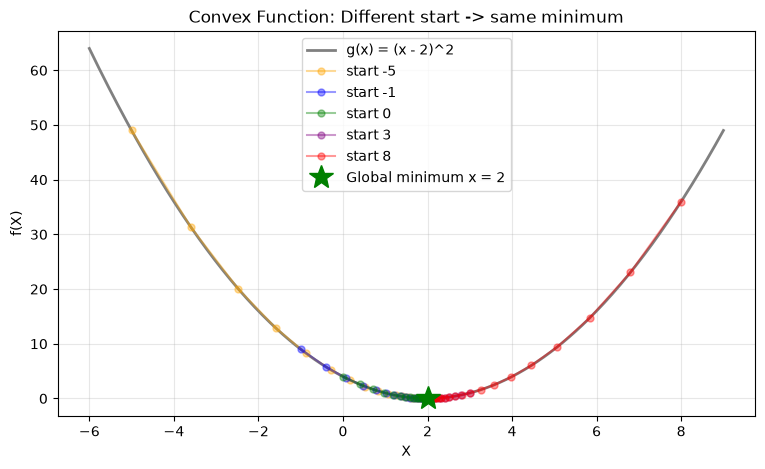

In [24]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x**4 - 4*x**2 + 0.4*x

def grad(x):
    return 4*x**3 - 8*x + 0.4

def gradient_descent(grad_fn, start, lr, steps):
    x = start
    history = [x]

    for _ in range(steps):
        x = x - lr * grad_fn(x) 
        history.append(x)

    return np.array(history)


# Run gradient descent from several starting points. 
starts = [-2.0, -0.5, 0.5, 2.2]

for start in starts:
    path = gradient_descent(grad, start, 0.01, 200)
    print(f"start {start} -> ends {path[-1]:.3f}")

# Plot function
x = np.linspace(-2.5, 2.5, 500)
y = f(x)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(x, y, color="black", lw=2, label="f(x)")

for start, color in [(-2.0, "orange"), (2.2, "red")]:
    path = gradient_descent(grad, start, 0.01, 200)
    ax.plot(path, f(path),"o-", color=color, alpha=0.5, markersize=5, 
            label=f"start {start:+.0f} -> ends {path[-1]:+.2f}")

ax.plot(-1.44, f(-1.44), "*", color="green", markersize=18, label="Deep global minimum")

ax.plot(1.40, f(1.40), "*", color="purple", markersize=18, label="Shallow local minimum")

ax.set_title("Same algorithm, different start -> different minimum")
ax.set_xlabel("X")
ax.set_ylabel("f(X)")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

# Print results
print("Global minimum (deepest) is on LEFT, near x = -1.44")
print("Shallow local minimum is on RIGHT, near x = +1.40")

# Convex Function
def g(x):
    return (x - 2) ** 2

def grad_g(x):
    return 2 * (x - 2)

# Run gradient descent from several starting points
print("\nConvex Function: g(x) = (x - 2)^2")

for start in [-5, -1, 0, 3, 8]:

    path = gradient_descent(grad_g, start, 0.1, 100)
    print(f"start {start} -> ends {path[-1]:.3f}")

# Plot convex function
x2 = np.linspace(-6, 9, 400)
y2 = g(x2)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x2, y2, color="Gray", lw=2, label="g(x) = (x - 2)^2")

# Plot descent paths
for start, color in [(-5, "orange"), (-1, "blue"), (0, "green"), (3, "purple"), (8, "red")]:
    path = gradient_descent(grad_g, start, 0.1, 100)
    ax.plot(path, g(path), "o-", color=color, alpha=0.4, markersize=5, label=f"start {start}")

# Mark a single minimum
ax.plot(2, g(2), "*", color="green", markersize=18, label="Global minimum x = 2")

ax.set_title("Convex Function: Different start -> same minimum")
ax.set_xlabel("X")
ax.set_ylabel("f(X)")
ax.legend()
ax.grid(alpha=0.3)

plt.show()



For the bumpy function, gradient descent can get trapped,
in different local minima depending on the starting point.

For the convex function, there is only one global minimum,
so different starting points converge to the same minimum.

Part C — 2D descent and escaping traps

TASK 05

Gradient descent in 2D on a contour plot

The curriculum's 2D activity. The same rule, now with a vector gradient.

Starting Point: [4. 4.]
Final Point: [5.31691198e-04 4.83570328e-16]


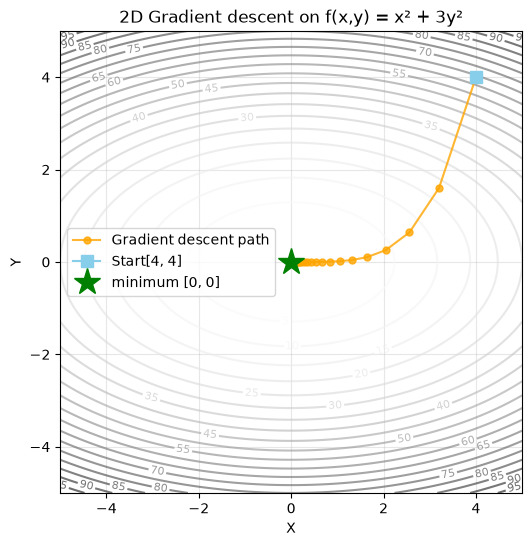

In [23]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return x ** 2 + 3 * y ** 2

def grad(p):
    return np.array([2 * p[0], 6 * p[1]])

# 2D gradient descent
def gradient_descent(start, lr, steps):
    p = np.array(start, dtype=float)
    path = [p.copy()]

    for _ in range(steps):
        p = p - lr * grad(p)
        path.append(p.copy())
    
    return np.array(path)    

# Starting Point
start = [4.0, 4.0]

# Learning Rate
lr = 0.1

# Run gradient descent
path = gradient_descent(start, lr, 40) 

print("Starting Point:", path[0])
print("Final Point:", path[-1])

# Contour plot
x = np.linspace(-5, 5, 300)
y = np.linspace(-5, 5, 300)

X, Y = np.meshgrid(x, y)
Z = f(X, Y)

fig, ax = plt.subplots(figsize=(8, 6))

contour = ax.contour(X, Y, Z, levels=20, cmap="Greys", alpha=0.6)
ax.clabel(contour, inline=True, fontsize=8)

ax.plot(path[:, 0], path[:, 1], "o-", color="orange", markersize=5, alpha=0.8, label="Gradient descent path")
ax.plot(path[0, 0], path[0, 1], marker="s", markersize=8, color="skyblue", label="Start[4, 4]")

ax.plot(0, 0, "*", color="green", markersize=20, label="minimum [0, 0]")

ax.set_title("2D Gradient descent on f(x,y) = x² + 3y²")
ax.set_xlabel("X")
ax.set_ylabel("Y")

ax.set_aspect("equal")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

TASK 06

Momentum: escape a shallow minimum

The deliverable finale. Give the ball inertia and watch it break free.

Starting Poing : 2.2
Plain GD final x : 1.3885174611929048
Plain GD final f(x) : -4.570600023966559


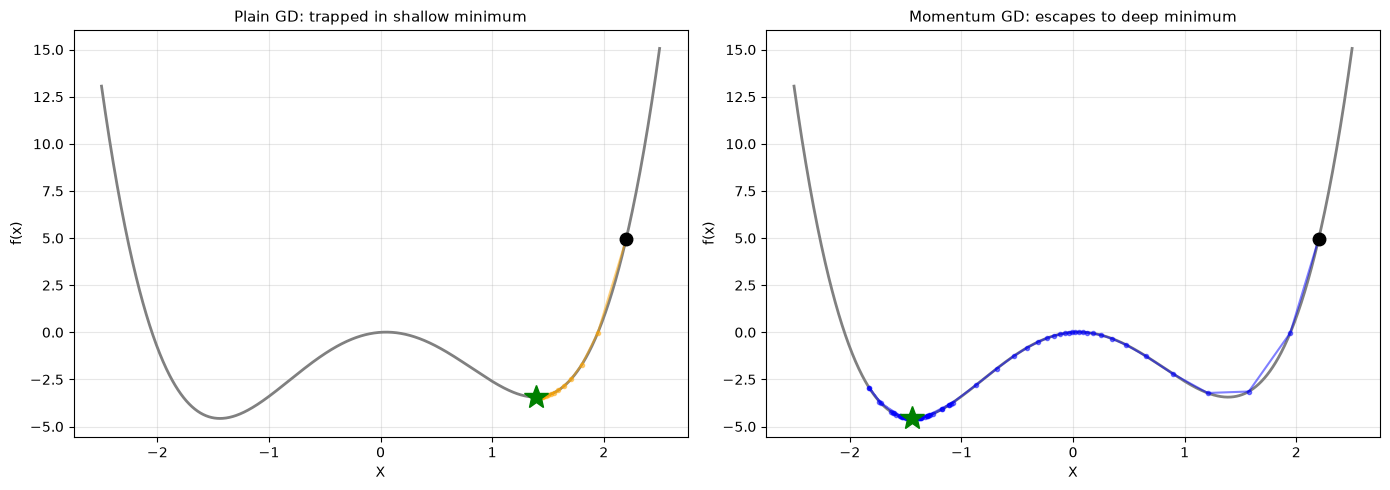

In [4]:
import numpy as np
import matplotlib.pyplot as plt


# Two minima function from Task 04
def f(x):
    return x**4 - 4*x**2 + 0.4*x

def grad(x):
    return 4*x**3 - 8*x + 0.4

# Plain Gradient Descent
def gradient_descent(start, lr=0.01, steps=800):
    x = start
    history = [x]

    for _ in range(steps):
        x = x - lr * grad(x)
        history.append(x)

    return np.array(history)

# Momentum gradient descent
def momentum_gd(start, lr=0.01, beta=0.9, steps=800):
    x = start
    v = 0.0
    hist = [x]

    for _ in range(steps):
        v = beta * v - lr * grad(x)
        x = x + v
        hist.append(x)
    
    return np.array(hist)


# Starting Point
start = 2.2

plain_path = gradient_descent(start, lr=0.01, steps=300)
momentum_path = momentum_gd(start, lr=0.01, beta=0.9, steps=800)

# Print Final position
print("Starting Poing :", start)
print("Plain GD final x :", plain_path[-1])
print("Plain GD final f(x) :", f(momentum_path[-1]))

# Function Curve
x_values = np.linspace(-2.5, 2.5, 1000)
y_values = f(x_values)

# Plot both side by side
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

for ax, path, ttl, color in [
    (ax[0], gradient_descent(2.2), "Plain GD: trapped in shallow minimum", "orange"),
    (ax[1], momentum_gd(2.2), "Momentum GD: escapes to deep minimum", "blue")]:
    ax.plot(x_values, y_values, color="gray", lw=2)
    ax.plot(path, f(path),"o-", color=color, alpha=0.5, markersize=3)
    ax.plot(path[0], f(path[0]), "o", color="black", markersize=9)
    ax.plot(path[-1], f(path[-1]), "*", color="green", markersize=18)
    ax.set_title(ttl, fontsize=11)
    ax.grid(alpha=0.3)
    ax.set_xlabel("X")
    ax.set_ylabel("f(x)")

plt.tight_layout()
plt.show()

Physical explanation:

Momentum carries the velocity of previous movement—much like a rolling ball—so that even after reaching a shallow valley, it retains enough inertia to climb over the hill. Plain gradient descent, however, considers only the current slope at each step; consequently, it stops as soon as the slope becomes zero at a shallow minimum.